In [7]:
import pandas as pd
URL = 'https://raw.githubusercontent.com/JeffSackmann/tennis_atp/master/atp_matches_2010.csv'
df = pd.read_csv(URL)

In [8]:
unique_players = set(df['winner_name']).union(set(df['loser_name']))
print(df.shape, len(unique_players), 'unique_players')



(3030, 49) 472 unique_players


In [9]:
top10 = (df.groupby('winner_name')
         .size()
         .sort_values(ascending=False)
         .head(10)
         .reset_index())
top10.columns = ['winner_name','wins']

print(top10)

       winner_name  wins
0     Rafael Nadal    71
1    Roger Federer    66
2   Novak Djokovic    63
3     David Ferrer    60
4  Robin Soderling    57
5    Jurgen Melzer    53
6     Andy Roddick    48
7      Andy Murray    46
8     Gael Monfils    46
9    Tomas Berdych    45


In [10]:
wins = (df.groupby('winner_name')
       .size()
       .rename('wins'))
losses = (df.groupby('loser_name')
       .size()
       .rename('losses'))
aces = (df.groupby('winner_name')['w_ace']
       .sum()
       .rename('aces'))
avg_min = (df.groupby('winner_name')['minutes']
       .mean()
       .rename('avg_min_won'))


In [11]:
stats = pd.concat([wins,losses,aces,avg_min], axis = 1).fillna(0)
stats['win_rate'] = stats['wins']/ (stats['wins'] + stats['losses'])
stats = stats.sort_values('wins', ascending=False).head(10)


In [12]:
#Helper function 

def win_rate_on(player, surface):
    wins = len(df[(df['winner_name'] == player) & (df['surface'] == surface)])
    losses = len(df[(df['loser_name'] == player) & (df['surface'] == surface)])
    total = wins + losses
    return wins/total if total>0 else 0

top10_names = stats.index.tolist()
pivot = pd.DataFrame({
    'Hard' : [win_rate_on(p, 'Hard') for p in top10_names],
    'Clay' : [win_rate_on(p, 'Clay') for p in top10_names],
    'Grass' : [win_rate_on(p, 'Grass') for p in top10_names],
}, index=top10_names
)


In [13]:
import sys
!"{sys.executable}" -m pip install matplotlib

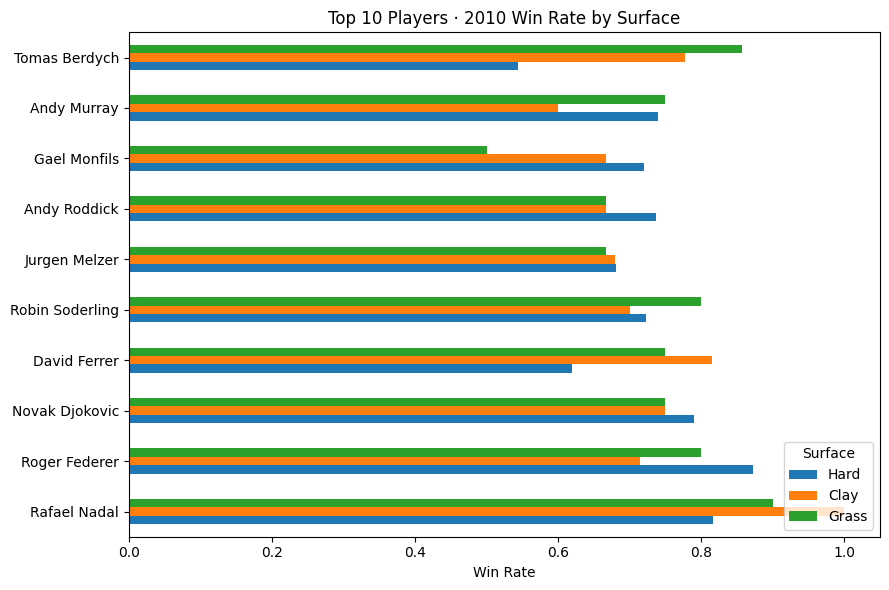

In [14]:


import matplotlib.pyplot as plt

ax = pivot.plot(kind='barh', figsize=(9, 6))
ax.set_xlabel('Win Rate')
ax.set_title('Top 10 Players · 2010 Win Rate by Surface')
ax.legend(title='Surface', loc='lower right')
plt.tight_layout()
plt.savefig('top10_surface_winrate.png', dpi=120)
plt.show()

In [25]:
import os
os.makedirs('data', exist_ok=True)
stats.to_csv('data/top10_stats_2010.csv')
# Add data/ to .gitignore if it isn't already — raw CSVs shouldn't live in git.

In [37]:
spread = pivot.max(axis=1) - pivot.min(axis=1)
spread.sort_values(ascending=False).head(3)


Tomas Berdych    0.313665
Gael Monfils     0.220000
David Ferrer     0.196742
dtype: float64

In [47]:
git status

SyntaxError: invalid syntax (3528599804.py, line 1)